# West Coast Wildfire Risk: Data Exploration and Final Dataset Creation

In [1]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import geopandas as gp
from scipy.spatial.distance import cdist
import datetime
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Uploading cleaned, lower dimensional datasets
fires = pd.read_csv(r'C:\Users\Melis\Downloads\Project1-Data\West-Coast-Wildfire-Data-Cleaned.csv')
weather = pd.read_csv(r'C:\Users\Melis\Downloads\Project1-Data\West-Coast-Weather-Data-Cleaned.csv')
pop = pd.read_csv(r'C:\Users\Melis\Downloads\Project1-Data\West-Coast-Population-by-County-Cleaned.csv')

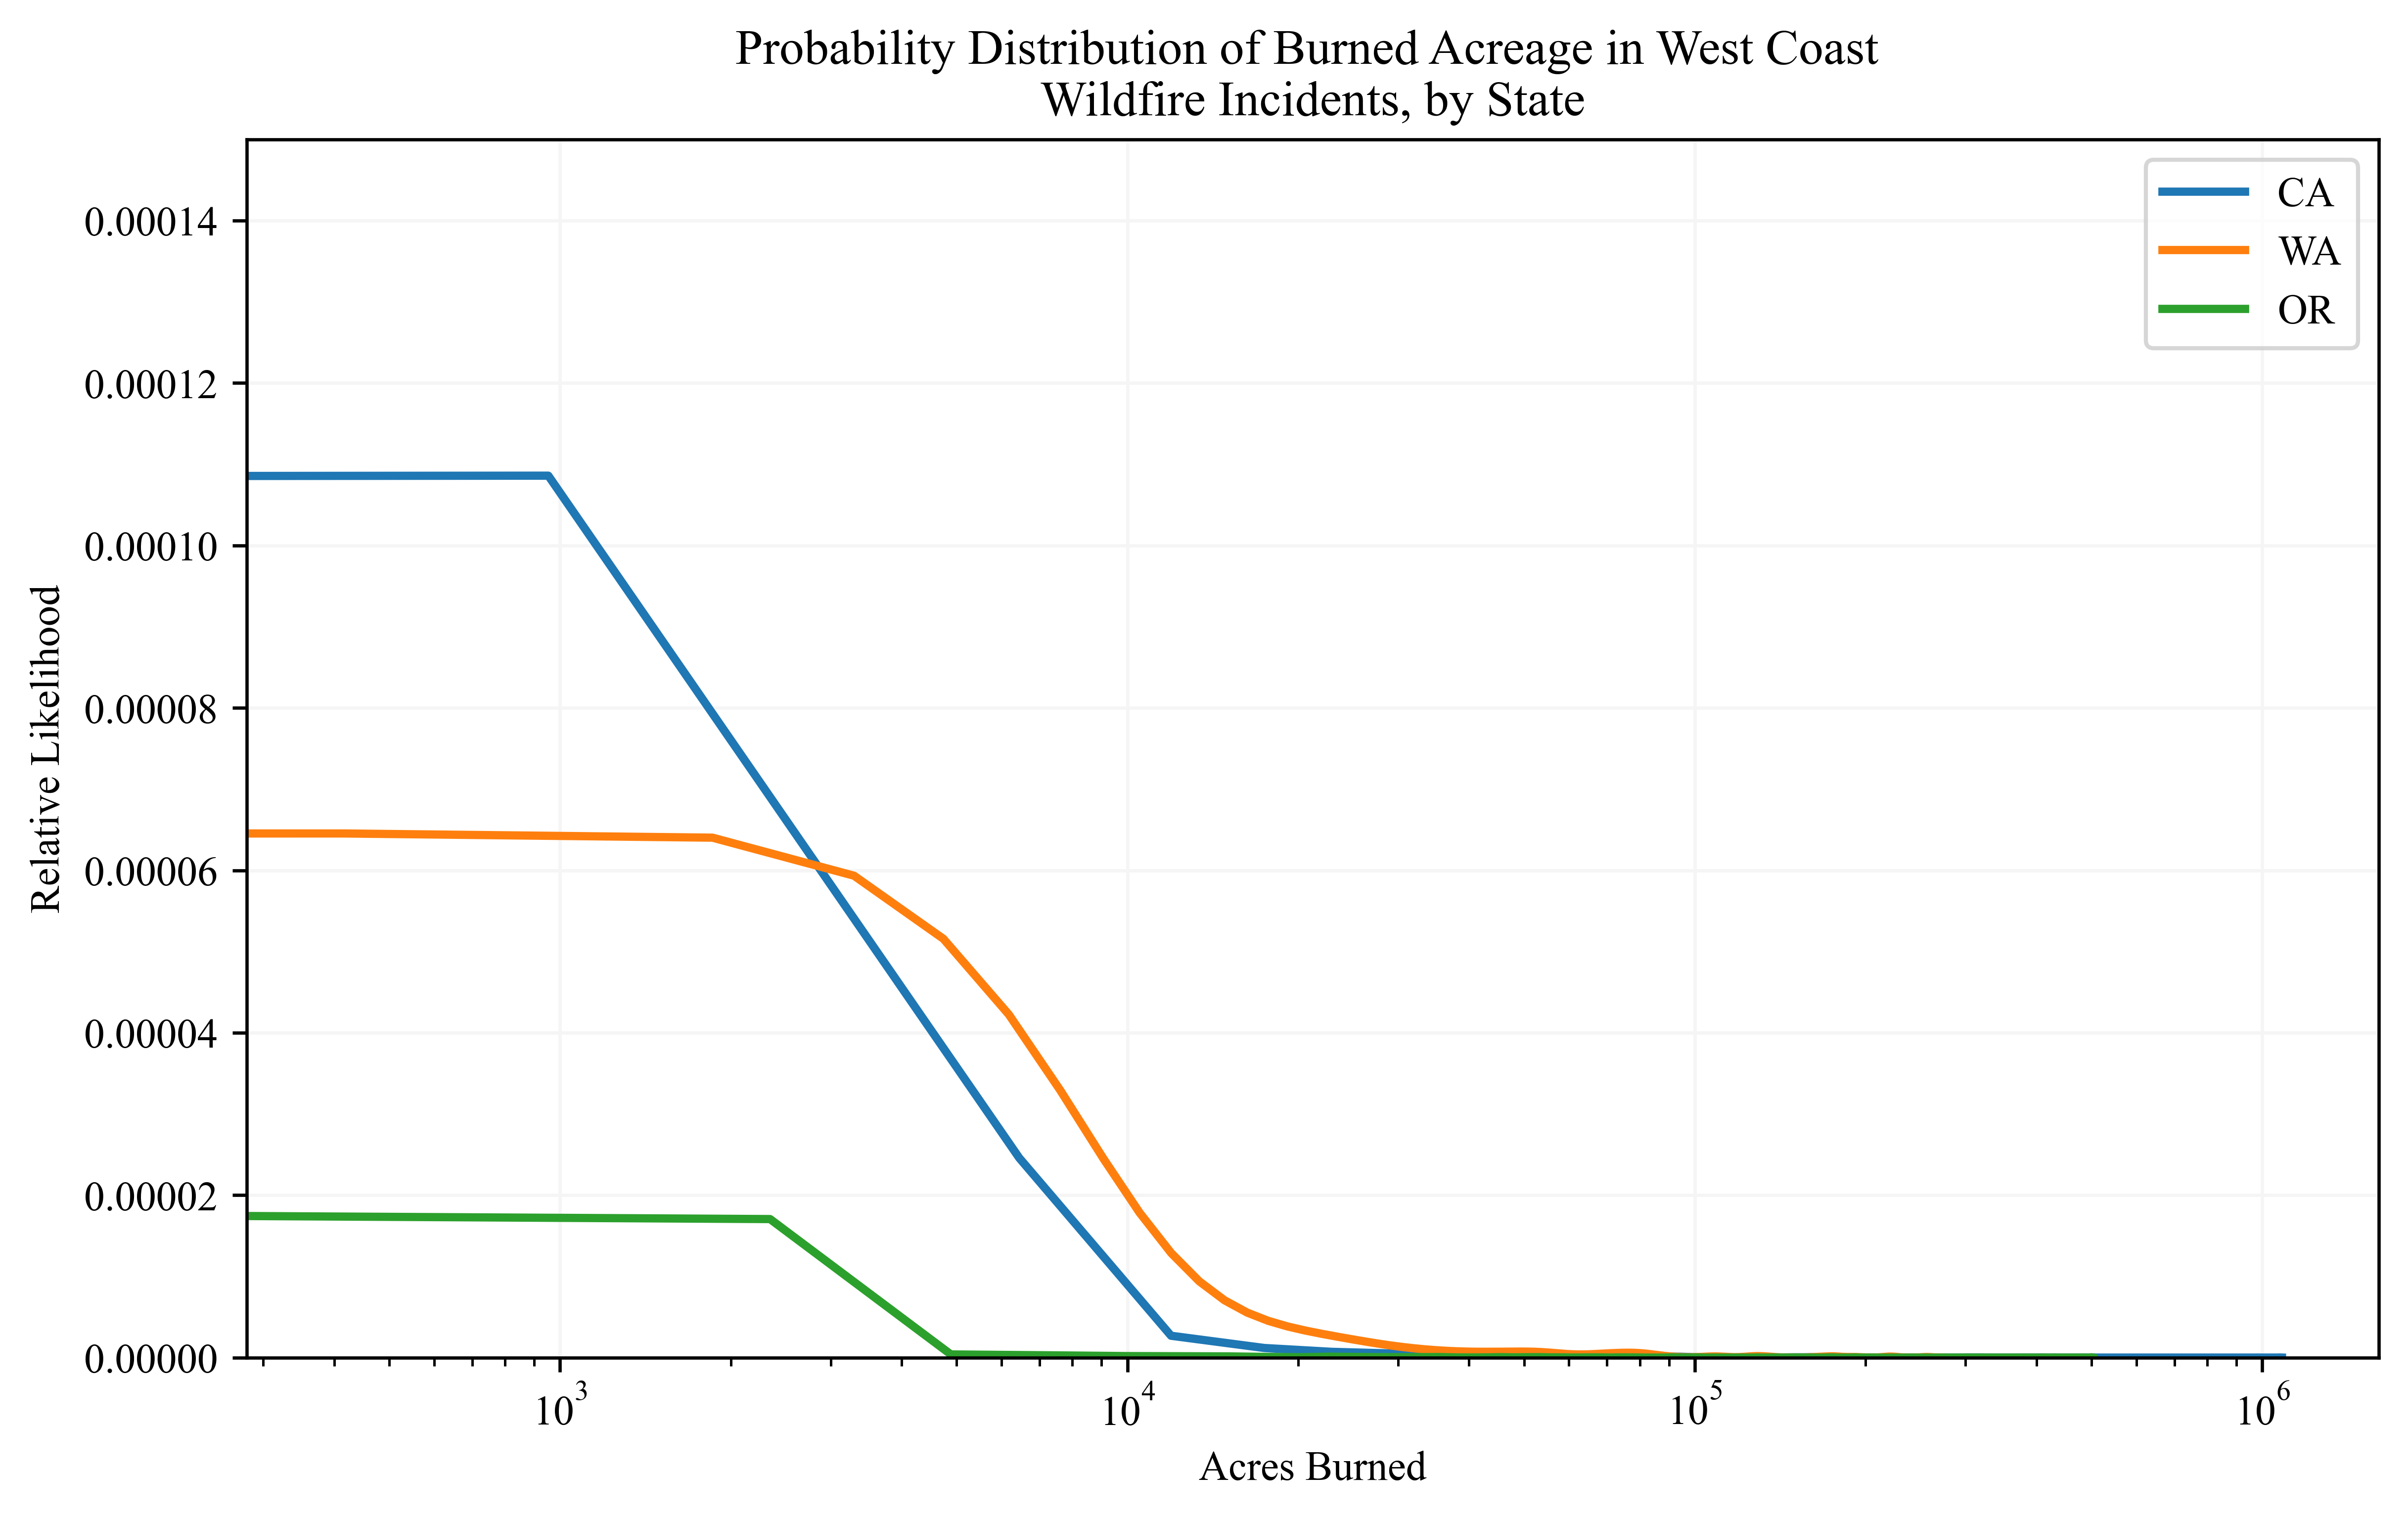

In [3]:
#Visualizing the relative likelihood of certain acerage being burned to understand what we might expect
caFires = fires[fires['STATE']=='CA']
waFires = fires[fires['STATE']=='WA']
orFires = fires[fires['STATE']=='OR']

plt.rcParams["font.family"] = "Times New Roman"
plt.figure(dpi=600, figsize=(8, 5), constrained_layout=True)

sns.kdeplot(caFires['ACRES'], fill=False, linewidth=2, label='CA')
sns.kdeplot(waFires['ACRES'], fill=False, linewidth=2, label='WA')
sns.kdeplot(orFires['ACRES'], fill=False, linewidth=2, label='OR')

plt.xscale('log')
plt.ylim(0, 0.00015)
plt.grid(True, color='whitesmoke', linewidth=0.8)
plt.legend()
plt.title('Probability Distribution of Burned Acreage in West Coast \nWildfire Incidents, by State')

plt.xlabel('Acres Burned')
plt.ylabel('Relative Likelihood')
plt.savefig("kde_acres_burned.png", dpi=600)

In [4]:
#Dropping duplicates from weather station data entires
ws = weather[['Name', 'Longitude', 'Latitude']].drop_duplicates()
print(ws)

            Name  Longitude  Latitude
0          Adams  -118.5607   46.9834
365       Asotin  -117.2031   46.1918
730       Benton  -119.5113   46.2398
1095      Chelan  -120.6189   47.8690
1460     Clallam  -123.9319   48.0490
...          ...        ...       ...
817055    Tulare  -118.8005   36.2201
817395  Tuolumne  -119.9553   38.0272
817735   Ventura  -119.0836   34.4566
818075      Yolo  -121.9017   38.6867
818415      Yuba  -121.3512   39.2690

[133 rows x 3 columns]


In [5]:
#Calculating the closest weather station to fire each event to see what the weather was like during the fire
#Calcultes the distance between two lat/log pairs
def haversine_distance_matrix(latlon1, latlon2):
    R = 6371.0  #Radius of the earth

    #Converting degrees to radians
    latlon1_rad = np.radians(latlon1)
    latlon2_rad = np.radians(latlon2)

    #Reshaping degrees so broadcasting works (matrix calc)
    lat1 = latlon1_rad[:, 0][:, np.newaxis]
    lon1 = latlon1_rad[:, 1][:, np.newaxis]
    lat2 = latlon2_rad[:, 0]
    lon2 = latlon2_rad[:, 1]

    #Finding pairwise difference 
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    #Applying the haversine formula
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))

    #Multiplying by earth's radius to get angles into distance
    return R * c  #Returning distance in km

#Getting the coordinates associated with fires and weather stations
fires_coords = fires[['LAT', 'LONG']].to_numpy()
stations_coords = ws[['Latitude', 'Longitude']].to_numpy()

#Compute distance matrix using the two lat/long pairs
distances = haversine_distance_matrix(fires_coords, stations_coords)

#Finding nearest weather station for each fire
nearest_idxs = distances.argmin(axis=1)
nearest_dists = distances[np.arange(len(fires)), nearest_idxs]

#Adding results to fire DataFrame
fires['WEATHER_STATION'] = ws.iloc[nearest_idxs].reset_index(drop=True)['Name'].values
fires['DISTANCE'] = nearest_dists

print(fires)

       Unnamed: 0                    FIRE  FIRE_NUM  START_DATE    END_DATE  \
0               0             RAIL CANYON   UNKNOWN  1994-08-01  1994-08-01   
1               1              CORK SCREW   UNKNOWN  1994-08-01  1994-08-01   
2               2                OWENS RD   UNKNOWN  1994-08-01  1994-08-01   
3               3  NEWKIRK - OLD TRAIL RD   UNKNOWN  1997-01-01  1997-01-01   
4               4               RIVERSIDE   UNKNOWN  1994-08-01  1994-08-01   
...           ...                     ...       ...         ...         ...   
34956       34956                   EIGHT  00000071  1990-10-08  1990-10-08   
34957       34957                    DEAD  00000110  1990-08-07  1990-08-08   
34958       34958                  RAGLAN  00000036  1990-08-08  1990-08-09   
34959       34959                          00000001  1990-03-18  1990-03-19   
34960       34960                          00000000  1990-01-05         NaN   

            ACRES  YEAR        LAT        LONG STAT

In [6]:
# Strip and parse fires
fires['WEATHER_STATION'] = fires['WEATHER_STATION'].astype(str).str.strip()
fires['START_DATE'] = pd.to_datetime(fires['START_DATE'], format='mixed', errors='coerce')
fires = fires.dropna(subset=['START_DATE'])  #Dropping rows that failed conversion
fires['START_DATE_ONLY'] = fires['START_DATE'].dt.date

# Strip and parse weather
weather['Name'] = weather['Name'].astype(str).str.strip()
weather['Date'] = pd.to_datetime(weather['Date'], format='mixed', errors='coerce')
weather = weather.dropna(subset=['Date'])  #Dropping rows that failed conversion
weather['DATE_ONLY'] = weather['Date'].dt.date


In [7]:
fires['merge_key'] = list(zip(fires['WEATHER_STATION'], fires['START_DATE_ONLY']))
weather['merge_key'] = list(zip(weather['Name'], weather['DATE_ONLY']))

In [8]:
merged_df = fires.merge(weather, on='merge_key', how='left')

In [9]:
merged_df = merged_df.drop(columns=['merge_key'])

In [10]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39616 entries, 0 to 39615
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Unnamed: 0_x        39616 non-null  int64         
 1   FIRE                39597 non-null  object        
 2   FIRE_NUM            33839 non-null  object        
 3   START_DATE          39616 non-null  datetime64[ns]
 4   END_DATE            38331 non-null  object        
 5   ACRES               39613 non-null  float64       
 6   YEAR                39616 non-null  int64         
 7   LAT                 39615 non-null  float64       
 8   LONG                39615 non-null  float64       
 9   STATE               39616 non-null  object        
 10  WEATHER_STATION     39616 non-null  object        
 11  DISTANCE            39615 non-null  float64       
 12  START_DATE_ONLY     39616 non-null  object        
 13  Unnamed: 0_y        38766 non-null  float64   

In [11]:
#Correcting county names (the ones longer than 12 characters) that were cut off
full_names = [
    'San Bernardino',
    'San Francisco',
    'San Luis Obispo',
    'Santa Barbara'
]

#Function to restore truncated names
def restore_full_name(truncated_name):
    for full in full_names:
        if full.startswith(truncated_name):
            return full
    return truncated_name  #Leaving unchanged if no match

#Applying to the merged DataFrame
merged_df['Name'] = merged_df['Name'].astype(str).str.strip()
merged_df['Name'] = merged_df['Name'].apply(restore_full_name)

In [12]:
merged_df.to_csv('test.csv')

In [14]:
merged_df = merged_df.merge(
    pop,
    left_on=['Name', 'State'],
    right_on=['County', 'State'],
    how='left'
)

In [15]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39616 entries, 0 to 39615
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Unnamed: 0_x                39616 non-null  int64         
 1   FIRE                        39597 non-null  object        
 2   FIRE_NUM                    33839 non-null  object        
 3   START_DATE                  39616 non-null  datetime64[ns]
 4   END_DATE                    38331 non-null  object        
 5   ACRES                       39613 non-null  float64       
 6   YEAR                        39616 non-null  int64         
 7   LAT                         39615 non-null  float64       
 8   LONG                        39615 non-null  float64       
 9   STATE                       39616 non-null  object        
 10  WEATHER_STATION             39616 non-null  object        
 11  DISTANCE                    39615 non-null  float64   

In [16]:
merged_df.to_csv('test.csv')

In [18]:
from sklearn.model_selection import train_test_split

X = pd.read_csv('Final-Analysis-Dataset-Project-1.csv')

# First split: 70% train, 30% temp
X_train, X_temp = train_test_split(X, test_size=0.3, random_state=42)

# Second split: from temp, 20% and 10% of original data
# Since temp is 30%, to get 20% and 10% splits, split temp into 2/3 and 1/3
X_val, X_test = train_test_split(X_temp, test_size=1/3, random_state=42)

print(len(X_train), len(X_val), len(X_test))

27731 7923 3962


In [19]:
X_train.to_csv('Final-Analysis-Training-Dataset-Project1.csv')
X_val.to_csv('Final-Analysis-Validation-Dataset-Project1.csv')
X_test.to_csv('Final-Analysis-Testing-Dataset-Project1.csv')

In [21]:
#Creating fire_risk column directly using pandas
X_train['fire_risk'] = 'Low'  # default
X_train.loc[X_train['ACRES'] >= 1, 'fire_risk'] = 'Medium'
X_train.loc[X_train['ACRES'] >= 500, 'fire_risk'] = 'High'

#Checking the results
print(X_train[['ACRES', 'fire_risk']].head(10))

#Saving updated dataset
X_train.to_csv("fire_data_with_risk.csv", index=False)

              ACRES fire_risk
31593    286.958397    Medium
25276      0.010000       Low
7667       0.010000       Low
33813  23628.892370      High
16615      0.100000       Low
21220      0.010000       Low
26939      0.010000       Low
18903      0.100000       Low
32566     32.438584    Medium
30463     27.991383    Medium


In [22]:
# Create fire_risk column directly using pandas' vectorized conditionsX_Train['fire_risk'] = 'Low'  # default
X_val['fire_risk'] = 'Low'  # default
X_val.loc[X_val['ACRES'] >= 1, 'fire_risk'] = 'Medium'
X_val.loc[X_val['ACRES'] >= 500, 'fire_risk'] = 'High'

# Check the results
print(X_val[['ACRES', 'fire_risk']].head(10))

# Save updated dataset
X_val.to_csv("fire_data_with_risk_val.csv", index=False)

             ACRES fire_risk
23955     0.010000       Low
37853    23.520242    Medium
30426    43.210486    Medium
1413      0.100000       Low
20084  1337.000000      High
21895     0.010000       Low
33459    16.008836    Medium
24932     1.000000    Medium
7650      0.010000       Low
27936     0.100000       Low
